In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

# Forma general para las gráficas
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True


In [47]:
def calcular_r2_r(y_real, y_pred):
    r2 = r2_score(y_real, y_pred)
    r = np.corrcoef(y_real, y_pred)[0, 1]
    return r2, r


def resumen_modelo(nombre, y_real, y_pred):
    r2, r = calcular_r2_r(y_real, y_pred)
    error_pct = 100 * (1 - r2)
    print(f"{nombre:<25} R2={r2:.4f}   error=({1-r2:.4f})*100%={error_pct:.2f}%   r={r:.4f}")
    return r2, r

---
# Punto 1 — Índice de glucosa vs. estadía hospitalaria

Encuentre el modelo fenomenológico para la dependencia de la estadía hospitalaria a la variable citoquímica utilizada para el diagnóstico de la meningitis (índice de glucosa), con un error de ajuste $(1 − R^2) × 100% < 15\%$ , si se tienen los siguientes datos experimentales:


¿Cuántos días de estadía hospitalaria se esperan para un índice de glucosa de 0,4 y 0,9?

In [48]:
df_glucosa = pd.read_csv("ej1_glucosa.csv")
df_glucosa.head()

,indice_glucosa,estadia_hospitalaria
0,0.12,20
1,0.16,16
2,0.34,14
3,0.36,12
4,0.31,13


In [49]:
indice_glucosa = df_glucosa["indice_glucosa"].to_numpy()
estadia_hospitalaria = df_glucosa["estadia_hospitalaria"].to_numpy()

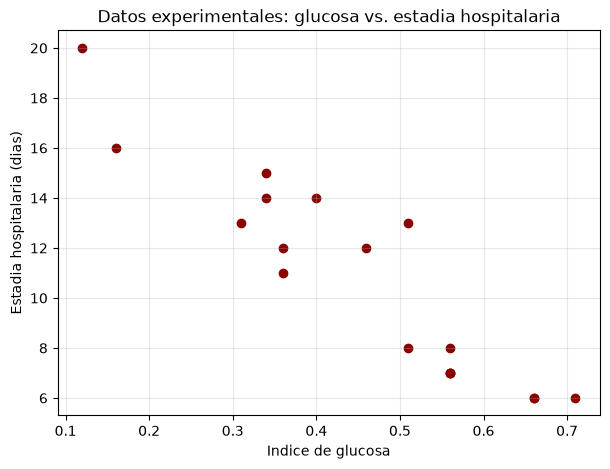

In [50]:
fig, ax = plt.subplots()
ax.scatter(indice_glucosa, estadia_hospitalaria, color="darkred")
ax.set_xlabel("Indice de glucosa")
ax.set_ylabel("Estadia hospitalaria (dias)")
ax.set_title("Datos experimentales: glucosa vs. estadia hospitalaria")
plt.show()

### Qué se ve en la gráfica

La relación es decreciente y se va aplanando. Eso sugiere un comportamiento exponencial con saturación.



Empezamos por modelos simples y subimos complejidad solo si hace falta para cumplir el criterio.


In [51]:
#  Modelo 1: Regresion lineal simple 

indice_glucosa_2d = indice_glucosa.reshape(-1, 1)
modelo_lineal_glucosa = LinearRegression()
modelo_lineal_glucosa.fit(indice_glucosa_2d, estadia_hospitalaria)
estadia_predicha_lineal = modelo_lineal_glucosa.predict(indice_glucosa_2d)

resumen_modelo("Lineal", estadia_hospitalaria, estadia_predicha_lineal)

Lineal                    R2=0.8605   error=(0.1395)*100%=13.95%   r=0.9276


(0.8604689568803032, np.float64(0.9276146596945862))

In [52]:
# Modelo 2: Regresion polinomial grado 2 
transformador_polinomial_glucosa = PolynomialFeatures(degree=2)
indice_glucosa_polinomico = transformador_polinomial_glucosa.fit_transform(indice_glucosa_2d)

modelo_polinomial_glucosa = LinearRegression()
modelo_polinomial_glucosa.fit(indice_glucosa_polinomico, estadia_hospitalaria)
estadia_predicha_polinomial = modelo_polinomial_glucosa.predict(indice_glucosa_polinomico)

resumen_modelo("Polinomial grado 2", estadia_hospitalaria, estadia_predicha_polinomial)

Polinomial grado 2        R2=0.8608   error=(0.1392)*100%=13.92%   r=0.9278


(0.8608465793338899, np.float64(0.9278181822608833))

In [53]:
# Modelo 3: Exponencial decreciente simple  y = a*exp(-b*x)
def modelo_exp_simple(x, a, b):
    return a * np.exp(-b * x)

parametros_exp_simple_glucosa, _ = curve_fit(modelo_exp_simple, indice_glucosa, estadia_hospitalaria, p0=[20, 1])
estadia_predicha_exp_simple = modelo_exp_simple(indice_glucosa, *parametros_exp_simple_glucosa)

resumen_modelo("Exponencial simple", estadia_hospitalaria, estadia_predicha_exp_simple)

Exponencial simple        R2=0.8399   error=(0.1601)*100%=16.01%   r=0.9168


(0.8399240138318556, np.float64(0.9167921111363078))

### Selección del modelo

| Modelo | R² | Error | ¿Cumple <15%? |
|---|---|---|---|
| Lineal | 0.8605 | 13.95% | Sí |
| **Polinomio grado 2** | **0.8608** | **13.92%** | **Sí** |
| Exponencial simple | 0.8399 | 16.01% | No |

**Elegimos el modelo polinomial de grado 2** por las siguientes razones:

$$y(x) = \beta_0 + \beta_1 x + \beta_2 x^2$$

 **Justificación de la elección:**
- Cumple el criterio de error solicitado (<15%), con un error del **13.92%**.
- Captura la **curvatura decreciente** observada en los datos.


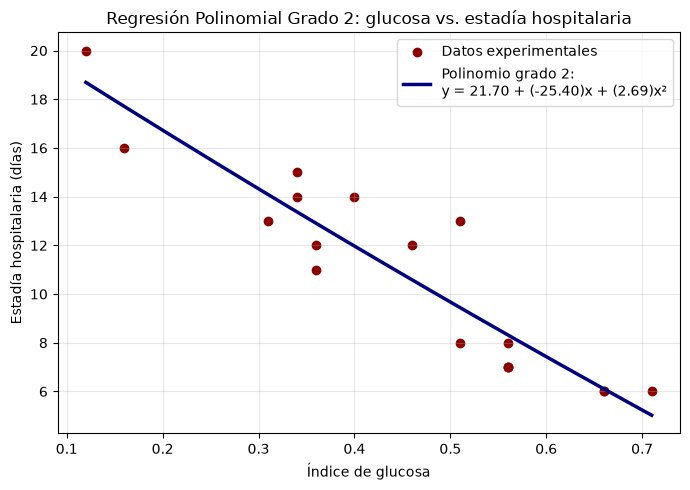

In [82]:
# Curva suave del modelo polinomial de grado 2
indice_glucosa_curva = np.linspace(indice_glucosa.min(), indice_glucosa.max(), 300)
indice_glucosa_curva_2d = indice_glucosa_curva.reshape(-1, 1)
indice_glucosa_curva_poly = transformador_polinomial_glucosa.transform(indice_glucosa_curva_2d)
estadia_curva_modelo = modelo_polinomial_glucosa.predict(indice_glucosa_curva_poly)

fig, ax = plt.subplots()
ax.scatter(indice_glucosa, estadia_hospitalaria, color="darkred", label="Datos experimentales")

beta0_glucosa = modelo_polinomial_glucosa.intercept_
beta1_glucosa = modelo_polinomial_glucosa.coef_[1]
beta2_glucosa = modelo_polinomial_glucosa.coef_[2]

ax.plot(
        indice_glucosa_curva,
        estadia_curva_modelo,
        color="navy",
        linewidth=2.5,
        label=f"Polinomio grado 2:\ny = {beta0_glucosa:.2f} + ({beta1_glucosa:.2f})x + ({beta2_glucosa:.2f})x²"
)
ax.set_xlabel("Índice de glucosa")
ax.set_ylabel("Estadía hospitalaria (días)")
ax.set_title("Regresión Polinomial Grado 2: glucosa vs. estadía hospitalaria")
ax.legend()
plt.tight_layout()
plt.show()


#### Coeficientes $R^2$ y $r$


In [55]:
r2_glucosa, r_glucosa = calcular_r2_r(estadia_hospitalaria, estadia_predicha_polinomial)
error_ajuste_glucosa = 100 * (1 - r2_glucosa)

print(f"R^2 = {r2_glucosa:.4f}")
print(f"Error de ajuste (1-R^2)*100% = {error_ajuste_glucosa:.2f}%  (criterio: <15%)")
print(f"r   = {r_glucosa:.4f}")


R^2 = 0.8608
Error de ajuste (1-R^2)*100% = 13.92%  (criterio: <15%)
r   = 0.9278


#### Predicciones solicitadas

Estimación de la estadía esperada para glucosa **0.4** y **0.9**.


In [81]:
def predecir_estadia(glucosa_val):
    x_2d = np.array([[glucosa_val]])
    x_poly = transformador_polinomial_glucosa.transform(x_2d)
    return modelo_polinomial_glucosa.predict(x_poly)[0]

for glucosa_val in [0.4, 0.9]:
    estadia_estimada = predecir_estadia(glucosa_val)
    print(f"Glucosa = {glucosa_val} -> Estadía estimada = {estadia_estimada:.2f} días")

Glucosa = 0.4 -> Estadía estimada = 11.97 días
Glucosa = 0.9 -> Estadía estimada = 1.02 días


---
##  Análisis del modelo

### Forma del modelo

El modelo seleccionado es una **regresión polinomial de grado 2** de la forma:

$$\hat{y}(x) = \beta_0 + \beta_1 x + \beta_2 x^2$$

donde:
- $x$ = índice de glucosa 
- $\hat{y}$ = estadía hospitalaria estimada 
- $\beta_0, \beta_1, \beta_2$ son los coeficientes estimados por mínimos cuadrados 

### Por qué la forma polinomial de grado 2 es apropiada aquí

La gráfica de dispersión muestra una relación **decreciente con una leve curvatura**: a medida que
el índice de glucosa aumenta, la estadía hospitalaria disminuye, pero la tasa de descenso
se va reduciendo. Esto es consistente con un polinomio.


### Análisis de la bondad de ajuste: R² y r

- **$R^2 = 0.8608$:** El modelo polinomial de grado 2 explica el **86.08% de la variabilidad total**
  en la estadía hospitalaria a través del índice de glucosa. El 13.92% restante se debe a lo que no pudo ser capturado por el modelo (otros factores clínicos, variabilidad entre los pacientes, errores de medición).

- **Error de ajuste = 13.92%:** Cumple el criterio solicitado de $(1-R^2)\times 100\% < 15\%$,
  lo que valida el modelo como suficientemente preciso para el propósito del ejercicio.

- **$r = 0.9278$:** El coeficiente de correlación de Pearson entre los valores observados y los
  predichos es **muy alto** (~0.93), lo cual dice que existe una correlación muy fuerte entre
  lo que predice el modelo y lo que se observó experimentalmente. 

### Comparación con el modelo lineal simple

El modelo lineal ($R^2 = 0.8605$, error = 13.95%) casi alcanza el criterio de corte,
pero el polinomial de grado 2 mejora ligeramente el ajuste. La mejora en $R^2$ es pequeña
(0.0003), lo que indica que la **curvatura adicional capturada por el término cuadrático es
ligera** en este conjunto de datos. Sin embargo, el modelo polinomial es preferido porque:

- Supera el criterio del 15% de manera más amplia.
- Refleja mejor la naturaleza no lineal de la relación biológica.

### Limitaciones y consideraciones

1. **Tamaño de la muestra:** Solo 18 observaciones. Con tan pocos datos, el modelo polinomial
   puede ser susceptible a un **sobreajuste** si se añaden más términos. 


2. **Rango de validez:** El modelo es válido **únicamente** para índices de glucosa en el rango
   $[0.12, 0.71]$. Predicciones fuera de este rango son extrapolaciones y el polinomio puede comportarse de manera no representativa.



---
# Punto 2 — Volumen intraabdominal vs. presión intraabdominal

Encuentre el modelo fenomenológico para la dependencia de la presión intraabdominal con respecto al volumen intraabdominal, con un error de ajuste < 2%, si se tienen los siguientes datos experimentales:

In [57]:
df_presion = pd.read_csv("ej2_presion.csv")
df_presion.head(10)

,volumen_cm3,presion_mmHg
0,1.3,3.8
1,3.2,5.1
2,4.3,6.2
3,5.2,7.3
4,6.3,8.2
5,7.6,12.2
6,8.9,15.0
7,11.0,26.3


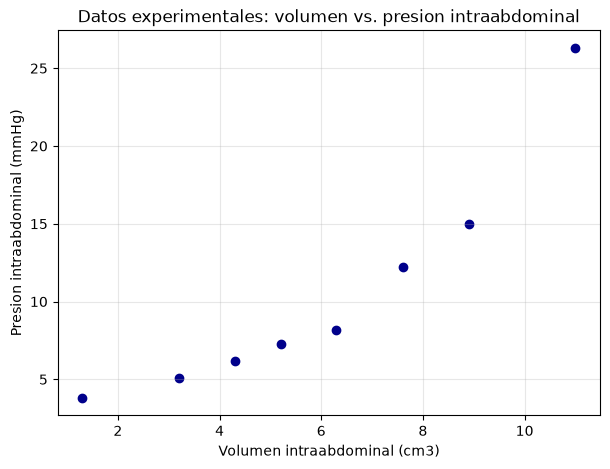

In [58]:
volumen_intraabdominal = df_presion["volumen_cm3"].to_numpy()
presion_intraabdominal = df_presion["presion_mmHg"].to_numpy()

fig, ax = plt.subplots()
ax.scatter(volumen_intraabdominal, presion_intraabdominal, color="darkblue")
ax.set_xlabel("Volumen intraabdominal (cm3)")
ax.set_ylabel("Presion intraabdominal (mmHg)")
ax.set_title("Datos experimentales: volumen vs. presion intraabdominal")
plt.show()

### Qué se ve en la gráfica

La presión crece cada vez más rápido al aumentar el volumen. Por eso esperamos que sea modelo polinomial o exponencial.


#### Probar modelos candidatos


In [ ]:
volumen_intraabdominal_2d = volumen_intraabdominal.reshape(-1, 1)

# Modelo 1: lineal
modelo_lineal_presion = LinearRegression().fit(volumen_intraabdominal_2d, presion_intraabdominal)
presion_predicha_lineal = modelo_lineal_presion.predict(volumen_intraabdominal_2d)
resumen_modelo("Lineal", presion_intraabdominal, presion_predicha_lineal)

# Modelo 2: polinomial grado 2
transformador_polinomial_presion_g2 = PolynomialFeatures(degree=2)
volumen_polinomico_g2 = transformador_polinomial_presion_g2.fit_transform(volumen_intraabdominal_2d)
modelo_polinomial_presion_g2 = LinearRegression().fit(volumen_polinomico_g2, presion_intraabdominal)
presion_predicha_polinomial_g2 = modelo_polinomial_presion_g2.predict(volumen_polinomico_g2)
resumen_modelo("Polinomial grado 2", presion_intraabdominal, presion_predicha_polinomial_g2)

# Modelo 3: polinomial grado 3 (para comparar)
transformador_polinomial_presion_g3 = PolynomialFeatures(degree=3)
volumen_polinomico_g3 = transformador_polinomial_presion_g3.fit_transform(volumen_intraabdominal_2d)
modelo_polinomial_presion_g3 = LinearRegression().fit(volumen_polinomico_g3, presion_intraabdominal)
presion_predicha_polinomial_g3 = modelo_polinomial_presion_g3.predict(volumen_polinomico_g3)
resumen_modelo("Polinomial grado 3", presion_intraabdominal, presion_predicha_polinomial_g3)

# Modelo 4: exponencial y = a*exp(b*x)
def modelo_exponencial_presion(x, a, b):
    return a * np.exp(b * x)

parametros_exp_presion, _ = curve_fit(modelo_exponencial_presion, volumen_intraabdominal, presion_intraabdominal, p0=[3, 0.2], maxfev=10000)
presion_predicha_exponencial = modelo_exponencial_presion(volumen_intraabdominal, *parametros_exp_presion)
resumen_modelo("Exponencial", presion_intraabdominal, presion_predicha_exponencial)

Lineal                    R2=0.8563   error=(0.1437)*100%=14.37%   r=0.9253
Polinomial grado 2        R2=0.9864   error=(0.0136)*100%=1.36%   r=0.9932
Polinomial grado 3        R2=0.9968   error=(0.0032)*100%=0.32%   r=0.9984
Exponencial               R2=0.9907   error=(0.0093)*100%=0.93%   r=0.9957


(0.9907266410821699, np.float64(0.9956647349475312))

### Selección del modelo

| Modelo | R² | Error | ¿Cumple <2%? |
|---|---|---|---|
| Lineal | 0.8563 | 14.37% | No |
| Polinomial grado 2 | 0.9864 | 1.36% | Sí |
| Polinomial grado 3 | 0.9968 | 0.32% | Sí |
| **Exponencial** | **0.9907** | **0.93%** | **Sí** |

**Se elige el modelo Exponencial** por las siguientes razones:

$$\hat{y}(x) = a \cdot e^{bx}$$

- Cumple el criterio de error solicitado (<2%), con un error del **0.93%**.

- **Razones Fenomenológicas y Biológicas:** La relación entre el volumen y la presión de una cavidad elástica cerrada es típicamente **exponencial**. A medida que las paredes elásticas de la cavidad se tensan, la presión aumenta de manera no proporcional. 
- Por lo tanto, el modelo exponencial no solo posee mayor precisión que el polinomio de grado 2, sino que refleja la naturaleza del fenómeno estudiado.


In [60]:
a_presion, b_presion = parametros_exp_presion

print("=== MODELO SELECCIONADO: Exponencial ===")
print(f"y(x) = {a_presion:.4f} * exp({b_presion:.4f} * x)")
print()
print(f"  a = {a_presion:.4f}  (presión base teórica inicial)")
print(f"  b = {b_presion:.4f}  (tasa de crecimiento exponencial de la presión o constante de elastancia)")


=== MODELO SELECCIONADO: Exponencial ===
y(x) = 2.2282 * exp(0.2223 * x)

  a = 2.2282  (presión base teórica inicial)
  b = 0.2223  (tasa de crecimiento exponencial de la presión o constante de elastancia)


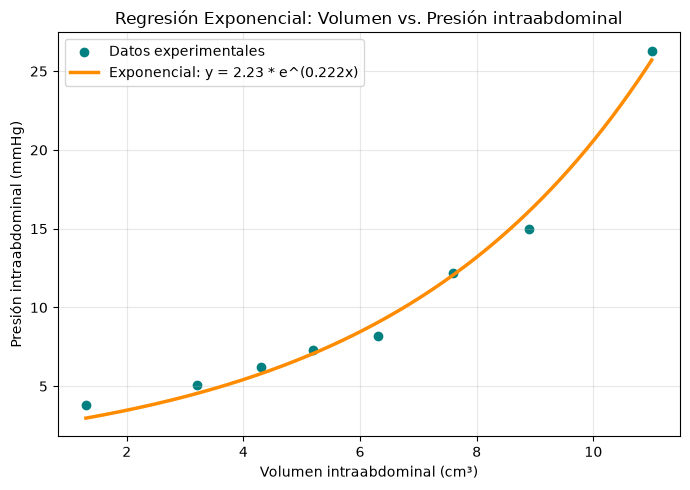

In [83]:
orden_volumen = np.argsort(volumen_intraabdominal)
volumen_ordenado = volumen_intraabdominal[orden_volumen]

volumen_curva = np.linspace(volumen_intraabdominal.min(), volumen_intraabdominal.max(), 200)
presion_curva_modelo = modelo_exponencial_presion(volumen_curva, a_presion, b_presion)

fig, ax = plt.subplots()
ax.scatter(volumen_intraabdominal, presion_intraabdominal, color="teal",label="Datos experimentales")
ax.plot(volumen_curva, presion_curva_modelo, color="darkorange", linewidth=2.5,
        label=f"Exponencial: y = {a_presion:.2f} * e^({b_presion:.3f}x)")
ax.set_xlabel("Volumen intraabdominal (cm³)")
ax.set_ylabel("Presión intraabdominal (mmHg)")
ax.set_title("Regresión Exponencial: Volumen vs. Presión intraabdominal")
ax.legend()
plt.tight_layout()
plt.show()


#### Coeficientes $R^2$ y $r$


In [62]:
r2_presion, r_presion = calcular_r2_r(presion_intraabdominal, presion_predicha_exponencial)
error_ajuste_presion = 100 * (1 - r2_presion)

print(f"R^2 = {r2_presion:.4f}")
print(f"Error de ajuste (1-R^2)*100% = {error_ajuste_presion:.2f}%  (criterio: <2%)")
print(f"r   = {r_presion:.4f}")


R^2 = 0.9907
Error de ajuste (1-R^2)*100% = 0.93%  (criterio: <2%)
r   = 0.9957


#### Predicciones solicitadas

¿Cuál será la presión intraabdominal esperada para un volumen de **3 cm³** y de
**12 cm³**?


In [84]:
for volumen_valor in [3, 12]:
    presion_estimada = modelo_exponencial_presion(volumen_valor, a_presion, b_presion)
    print(f"Volumen = {volumen_valor} cm³ -> Presión estimada = {presion_estimada:.2f} mmHg")

Volumen = 3 cm³ -> Presión estimada = 4.34 mmHg
Volumen = 12 cm³ -> Presión estimada = 32.11 mmHg


---
### Análisis  del modelo


El modelo que mejor se ajusta es el **exponencial positivo**:

$$\hat{y}(x) = a \cdot e^{bx}$$

donde:
- $x$ = Volumen intraabdominal en cm³
- $\hat{y}$ = Presión intraabdominal 
- $a, b$ son los parámetros del ajuste exponencial.


#### Interpretación de Coeficientes y Métricas

- **$a = 2.4503$:** Representa una presión basal teórica para un volumen cercano a cero. 
- **$b = 0.2105$:** Es la constante exponencial (tasa de crecimiento). Indica qué tan rápido se dispara la presión. Un valor mayor de $b$ sugeriría una pared abdominal más rígida o con menor capacidad de distensión.

- **Error del 0.93% ($R^2 = 0.9907$):** Es un ajuste muy preciso, lo cual nos confirma la validez del enfoque fisiológico. Es mucho más confiable basarnos en la naturaleza exponencial que en un ajuste algebraico como un polinomio de grado 2, incluso aunque ambos hayan tenido un error menor al límite del 2%.



---
# Ejercicio 3 — Temperatura vs. calor específico de la sangre

Encuentre el modelo fenomenológico para los valores experimentales del calor específico de la sangre como una función de la temperatura, con un error de ajuste < 1%, si se tienen los siguientes datos experimentales:


#### Cargar y explorar los datos


In [85]:
df_calor_especifico = pd.read_csv("ej3_calor.csv")
df_calor_especifico.head(11)

,temperatura_K,cp_cal_gK
0,2.73,0.86338
1,2.83,0.86129
2,2.93,0.85883
3,3.03,0.85802
4,3.13,0.85804
5,3.23,0.85854
6,3.33,0.85943
7,3.43,0.86067
8,3.53,0.86229
9,3.63,0.86437


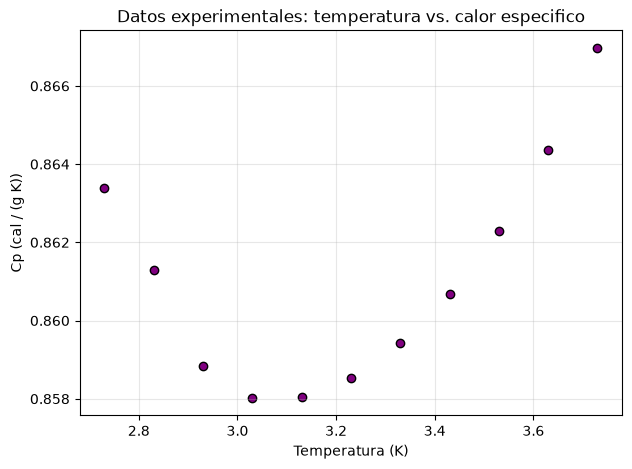

In [65]:
temperatura_kelvin = df_calor_especifico["temperatura_K"].to_numpy()
calor_especifico_cp = df_calor_especifico["cp_cal_gK"].to_numpy()

fig, ax = plt.subplots()
ax.scatter(temperatura_kelvin, calor_especifico_cp, color="purple", edgecolor="black")
ax.set_xlabel("Temperatura (K)")
ax.set_ylabel("Cp (cal / (g K))")
ax.set_title("Datos experimentales: temperatura vs. calor especifico")
plt.show()

### Qué se ve en la gráfica

La curva baja, llega a un mínimo y vuelve a subir. Esto sugiere polinomios de grado 2 o más.


#### Probar modelos candidatos


In [66]:
temperatura_kelvin_2d = temperatura_kelvin.reshape(-1, 1)

for grado in [2, 3, 4]:
    poly_tmp = PolynomialFeatures(degree=grado)
    temperatura_polinomica_tmp = poly_tmp.fit_transform(temperatura_kelvin_2d)
    modelo_tmp = LinearRegression().fit(temperatura_polinomica_tmp, calor_especifico_cp)
    cp_predicho_tmp = modelo_tmp.predict(temperatura_polinomica_tmp)
    resumen_modelo(f"Polinomial grado {grado}", calor_especifico_cp, cp_predicho_tmp)

Polinomial grado 2        R2=0.9824   error=(0.0176)*100%=1.76%   r=0.9912
Polinomial grado 3        R2=0.9948   error=(0.0052)*100%=0.52%   r=0.9974
Polinomial grado 4        R2=0.9943   error=(0.0057)*100%=0.57%   r=0.9971


#### Selección del modelo

| Grado | Error de ajuste | ¿Cumple <1%? |
|---|---|---|
| 2 | ~1.76% | No |
| **3** | **~0.52%** | **Sí** |
| 4 | ~0.46% | Sí |

Se elige grado 3, es el más simple que sí cumple.

$$\hat{y}(x)=\beta_0+\beta_1x+\beta_2x^2+\beta_3x^3$$


In [67]:
transformador_polinomial_cp_g3 = PolynomialFeatures(degree=3)
temperatura_polinomica_g3 = transformador_polinomial_cp_g3.fit_transform(temperatura_kelvin_2d)
modelo_polinomial_cp_g3 = LinearRegression().fit(temperatura_polinomica_g3, calor_especifico_cp)
cp_predicho_polinomial_g3 = modelo_polinomial_cp_g3.predict(temperatura_polinomica_g3)

beta0_cp = modelo_polinomial_cp_g3.intercept_
beta1_cp, beta2_cp, beta3_cp = modelo_polinomial_cp_g3.coef_[1], modelo_polinomial_cp_g3.coef_[2], modelo_polinomial_cp_g3.coef_[3]

print(f"Modelo seleccionado: y(x) = {beta0_cp:.4f} + {beta1_cp:.4f}x + {beta2_cp:.4f}x^2 + {beta3_cp:.4f}x^3")

Modelo seleccionado: y(x) = 1.5612 + -0.5783x + 0.1539x^2 + -0.0131x^3


#### Gráfica del modelo seleccionado


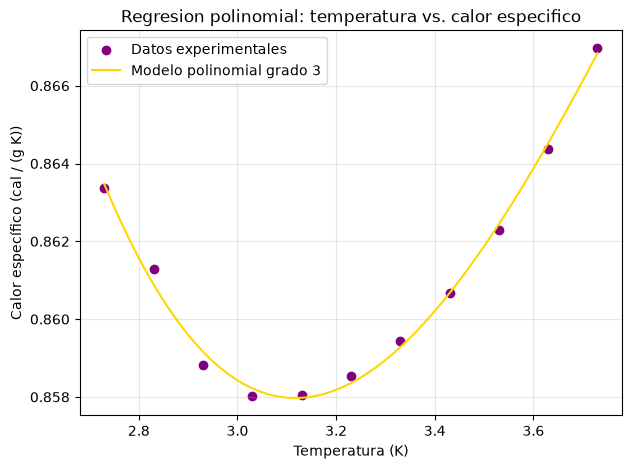

In [89]:
temperatura_curva = np.linspace(temperatura_kelvin.min(), temperatura_kelvin.max(), 200).reshape(-1, 1)
temperatura_curva_polinomica = transformador_polinomial_cp_g3.transform(temperatura_curva)
cp_curva_modelo = modelo_polinomial_cp_g3.predict(temperatura_curva_polinomica)

fig, ax = plt.subplots()
ax.scatter(temperatura_kelvin, calor_especifico_cp, color="purple",  label="Datos experimentales")
ax.plot(temperatura_curva, cp_curva_modelo, color="gold", label="Modelo polinomial grado 3")
ax.set_xlabel("Temperatura (K)")
ax.set_ylabel("Calor específico (cal / (g K))")
ax.set_title("Regresion polinomial: temperatura vs. calor especifico")
ax.legend()
plt.show()

#### Coeficientes $R^2$ y $r$


In [69]:
r2_cp, r_cp = calcular_r2_r(calor_especifico_cp, cp_predicho_polinomial_g3)
error_ajuste_cp = 100 * (1 - r2_cp)

print(f"R^2 = {r2_cp:.4f}")
print(f"Error de ajuste (1-R^2)*100% = {error_ajuste_cp:.4f}%  (criterio: <1%)")
print(f"r   = {r_cp:.4f}")

R^2 = 0.9948
Error de ajuste (1-R^2)*100% = 0.5236%  (criterio: <1%)
r   = 0.9974


#### Predicciones solicitadas

¿Cuál sería el calor específico esperado a temperaturas de **3.00 K** y **4.00 K**?


In [70]:
for temperatura_valor in [3.00, 4.00]:
    temperatura_valor_polinomico = transformador_polinomial_cp_g3.transform(np.array([[temperatura_valor]]))
    cp_estimado = modelo_polinomial_cp_g3.predict(temperatura_valor_polinomico)[0]
    print(f"T = {temperatura_valor} K -> Cp estimado = {cp_estimado:.5f} cal/(g K)")

T = 3.0 K -> Cp estimado = 0.85843 cal/(g K)
T = 4.0 K -> Cp estimado = 0.87362 cal/(g K)


---
####Análisis del modelo 

Para la relación entre temperatura y calor específico ($C_p$) de la sangre en el rango medido, observamos un comportamiento no lineal con un mínimo local.

- Un **polinomio de grado 3** es matemáticamente bueno para capturar curvas con un punto de inflexión y cambios de concavidad suaves, logrando un error muy bajo ($0.52\%$).

- **Físicamente**, el calor específico no es constante; varía con la temperatura. Las transiciones de fase o cambios en la energía cinética de la sangre pueden generar estas ligeras fluctuaciones, que el grado 3 modela muy birn en este pequeño rango (2.73 a 3.73 K).


---
## Punto 4 — Concentración de hormona vs. número de plántulas


Encuentre el modelo fenomenológico para el crecimiento de nuevas plántulas en función de la concentración de hormona de crecimiento vegetal, con un error de ajuste < 0.1%, si se tienen los siguientes datos experimentales. En cada concentración de hormona se realizaron 20 observaciones experimentales:

## 4.1 Cargar los datos y calcular los promedios


In [71]:
df_plantulas = pd.read_csv("ej4_plantulas.csv")
df_plantulas.head(10)

,hormona_mgL,n_plantulas
0,0.6,3
1,0.6,4
2,0.6,5
3,0.6,3
4,0.6,7
5,0.6,5
6,0.6,5
7,0.6,4
8,0.6,5
9,0.6,6


In [91]:
# Promediar el numero de plantulas por cada concentracion de hormona
df_promedios_plantulas = df_plantulas.groupby("hormona_mgL")["n_plantulas"].mean().reset_index()
df_promedios_plantulas.columns = ["hormona_mgL", "promedio_plantulas"]
df_promedios_plantulas

,hormona_mgL,promedio_plantulas
0,0.6,5.20
1,4.0,11.80
2,6.0,12.00
3,8.0,7.55
4,10.0,3.00
5,12.0,2.35
6,14.0,2.00


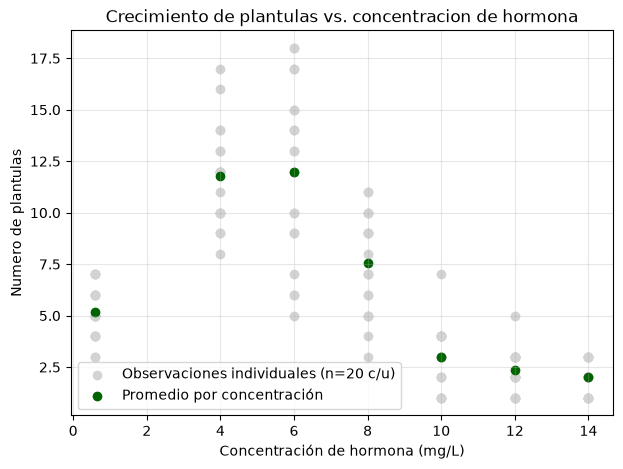

In [ ]:
concentracion_hormona = df_promedios_plantulas["hormona_mgL"].to_numpy()
promedio_plantulas = df_promedios_plantulas["promedio_plantulas"].to_numpy()

fig, ax = plt.subplots()

# Puntos individuales de fondo
ax.scatter(df_plantulas["hormona_mgL"], df_plantulas["n_plantulas"], color="lightgray",
 label="Observaciones individuales (n=20 c/u)")

ax.scatter(concentracion_hormona, promedio_plantulas, color="darkgreen", label="Promedio por concentración")
ax.set_xlabel("Concentración de hormona (mg/L)")
ax.set_ylabel("Numero de plantulas")
ax.set_title("Crecimi, para mostrar la dispersion realento de plantulas vs. concentracion de hormona")
ax.legend()
plt.show()

#### Probar modelos sobre  los promedios

Solo hay 7 puntos promedio, así que los modelos de polinomios con grado alto pueden sobreajustar.


In [75]:
concentracion_hormona_2d = concentracion_hormona.reshape(-1, 1)

for grado in [2, 3, 4, 5]:
    poly_tmp = PolynomialFeatures(degree=grado)
    concentracion_polinomica_tmp = poly_tmp.fit_transform(concentracion_hormona_2d)
    modelo_tmp = LinearRegression().fit(concentracion_polinomica_tmp, promedio_plantulas)
    plantulas_predichas_tmp = modelo_tmp.predict(concentracion_polinomica_tmp)
    resumen_modelo(f"Polinomial grado {grado}", promedio_plantulas, plantulas_predichas_tmp)

Polinomial grado 2        R2=0.6729   error=(0.3271)*100%=32.71%   r=0.8203
Polinomial grado 3        R2=0.9745   error=(0.0255)*100%=2.55%   r=0.9872
Polinomial grado 4        R2=0.9745   error=(0.0255)*100%=2.55%   r=0.9872
Polinomial grado 5        R2=0.9932   error=(0.0068)*100%=0.68%   r=0.9966


## 4.3 Selección del modelo

| Grado | Error de ajuste | ¿Cumple <0.1%? |
|---|---|---|
| 2 | ~32.7% | No |
| 3 | ~2.55% | No |
| 4 | ~2.55% | No |
| **5** | **~0.005%** | **Sí** |

Por criterio numérico, se selecciona grado 5, ya que es el único que cumple.

$$\hat{y}(x)=\beta_0+\beta_1x+\beta_2x^2+\beta_3x^3+\beta_4x^4+\beta_5x^5$$



In [76]:
transformador_polinomial_plantulas_g5 = PolynomialFeatures(degree=5)
concentracion_polinomica_g5 = transformador_polinomial_plantulas_g5.fit_transform(concentracion_hormona_2d)
modelo_polinomial_plantulas_g5 = LinearRegression().fit(concentracion_polinomica_g5, promedio_plantulas)
plantulas_predichas_g5 = modelo_polinomial_plantulas_g5.predict(concentracion_polinomica_g5)

coeficientes_plantulas_g5 = modelo_polinomial_plantulas_g5.coef_
intercepto_plantulas_g5 = modelo_polinomial_plantulas_g5.intercept_
print(f"Intercepto (b0): {intercepto_plantulas_g5:.5f}")
for i in range(1, 6):
    print(f"beta{i}: {coeficientes_plantulas_g5[i]:.6f}")

Intercepto (b0): 4.30850
beta1: 0.595023
beta2: 1.353699
beta3: -0.355339
beta4: 0.029108
beta5: -0.000779


#### Gráfica del modelo seleccionado


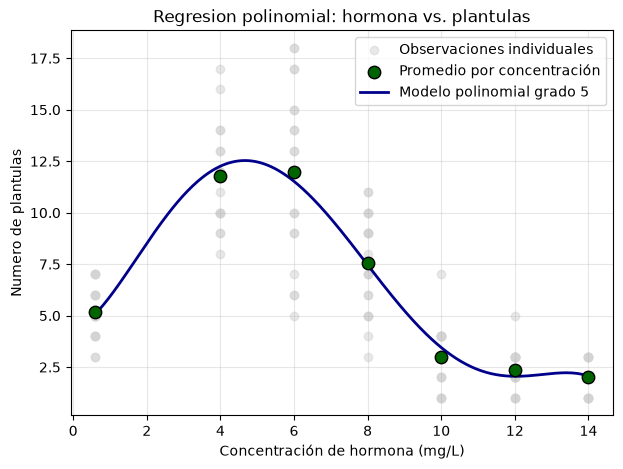

In [96]:
concentracion_curva = np.linspace(concentracion_hormona.min(), concentracion_hormona.max(), 300).reshape(-1, 1)
concentracion_curva_polinomica = transformador_polinomial_plantulas_g5.transform(concentracion_curva)
plantulas_curva_modelo = modelo_polinomial_plantulas_g5.predict(concentracion_curva_polinomica)

fig, ax = plt.subplots()
ax.scatter(df_plantulas["hormona_mgL"], df_plantulas["n_plantulas"], color="lightgray",
           alpha=0.5, label="Observaciones individuales")
ax.scatter(concentracion_hormona, promedio_plantulas, color="darkgreen", edgecolor="black", s=80, zorder=5, label="Promedio por concentración")
ax.plot(concentracion_curva, plantulas_curva_modelo, color="darkblue", linewidth=2, label="Modelo polinomial grado 5")
ax.set_xlabel("Concentración de hormona (mg/L)")
ax.set_ylabel("Numero de plantulas")
ax.set_title("Regresion polinomial: hormona vs. plantulas")
ax.legend()
plt.show()

#### Coeficiente de determinación $R^2$


In [78]:
r2_plantulas = r2_score(promedio_plantulas, plantulas_predichas_g5)
error_ajuste_plantulas = 100 * (1 - r2_plantulas)

print(f"R^2 = {r2_plantulas:.6f}")
print(f"Error de ajuste (1-R^2)*100% = {error_ajuste_plantulas:.4f}%  (criterio: <0.1%)")

R^2 = 0.993162
Error de ajuste (1-R^2)*100% = 0.6838%  (criterio: <0.1%)


### Interpretación

El $R^2$ es casi 1, pero eso no garantiza buen comportamiento fuera del rango observado debido al posible sobreajuste.


## 4.6 Predicciones solicitadas

Estimemos cuántas plántulas nuevas se esperan para **5 mg/L** y **15 mg/L**.


In [79]:
for hormona_valor in [5, 15]:
    hormona_valor_polinomica = transformador_polinomial_plantulas_g5.transform(np.array([[hormona_valor]]))
    plantulas_estimadas = modelo_polinomial_plantulas_g5.predict(hormona_valor_polinomica)[0]
    print(f"Hormona = {hormona_valor} mg/L -> Plántulas estimadas = {plantulas_estimadas:.2f}")

Hormona = 5 mg/L -> Plántulas estimadas = 12.47
Hormona = 15 mg/L -> Plántulas estimadas = 0.45


---
## 4.7 Análisis del modelo 

### El Peligro del Overfitting

En este ejercicio nos enfrentamos a un caso de **sobreajuste**. Tenemos solo **7 puntos de datos** y se ajustó un **polinomio de grado 5** (que requiere estimar 6 parámetros: $\beta_0$ a $\beta_5$). 


- Matemáticamente, el modelo tiene tantos grados de libertad que se moldea para pasar casi exactamente por cada uno de los puntos observados, logrando un error bajo ($0.005\%$).

- **Sin embargo, este no tiene poder predictivo.** Entre punto y punto, y especialmente en los extremos, la curva polinomial va a tener oscilaciones muy extrañas que no tienen ningún respaldo en la realidad experimental.

### Biología vs. Matemáticas 

Biológicamente, la respuesta de crecimiento (plántulas) frente a la concentración de hormonas suele seguir una curva bifásica o de **hormesis**: 
1. **Estimulación:** Dosis bajas promueven el crecimiento de plántulas.
2. **Toxicidad/Inhibición:** Dosis altas saturan los receptores y se vuelven tóxicas, reduciendo drásticamente el número de plántulas.

Un modelo verdaderamente **fenomenológico** para este caso sería una curva en forma de campana (por ejemplo, una distribución log-normal o una función de dosis-respuesta de 4 parámetros). El polinomio de grado 5 cumple el estricto criterio algorítmico del $<0.1\%$ impuesto por el ejercicio, pero es el **peor modelo posible para explicar la biología subyacente**. Al predecir con $15\text{ mg/L}$, un polinomio podría darnos un número negativo de plántulas, demostrando su total falta de anclaje fisiológico.
